# Лабораторная работа №2 "Апроксимация нелинейных функций"

**Цель работы:** изучить построение полносвязных нейронных сетей для аппроксимации нелинейной функции и сравнить обычную последовательную архитектуру с ветвящейся сетью.

## Лабораторная работа №2. Часть 1

In [47]:
# Установка дополнительных пакетов
!pip install torchsummary torchinfo torchview

In [48]:
# Базовые библиотеки
import math
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torchinfo import summary as info_summary
from torchview import draw_graph

# Устройство вычислений (CPU / GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

# (опционально) инструменты для вывода архитектуры
try:
    from torchsummary import summary
except ImportError:
    summary = None

Используемое устройство: cuda


In [49]:
# Создание обучающей выборки
t0 = np.arange(0, 1, 0.001, dtype=np.float32)
t  = 2 * math.pi * t0
x  = (np.cos(t) / 2).astype(np.float32)

# Преобразуем в тензоры PyTorch
X = torch.from_numpy(t0.reshape(-1, 1))  # входы (N, 1)
y = torch.from_numpy(x.reshape(-1, 1))   # целевые значения (N, 1)

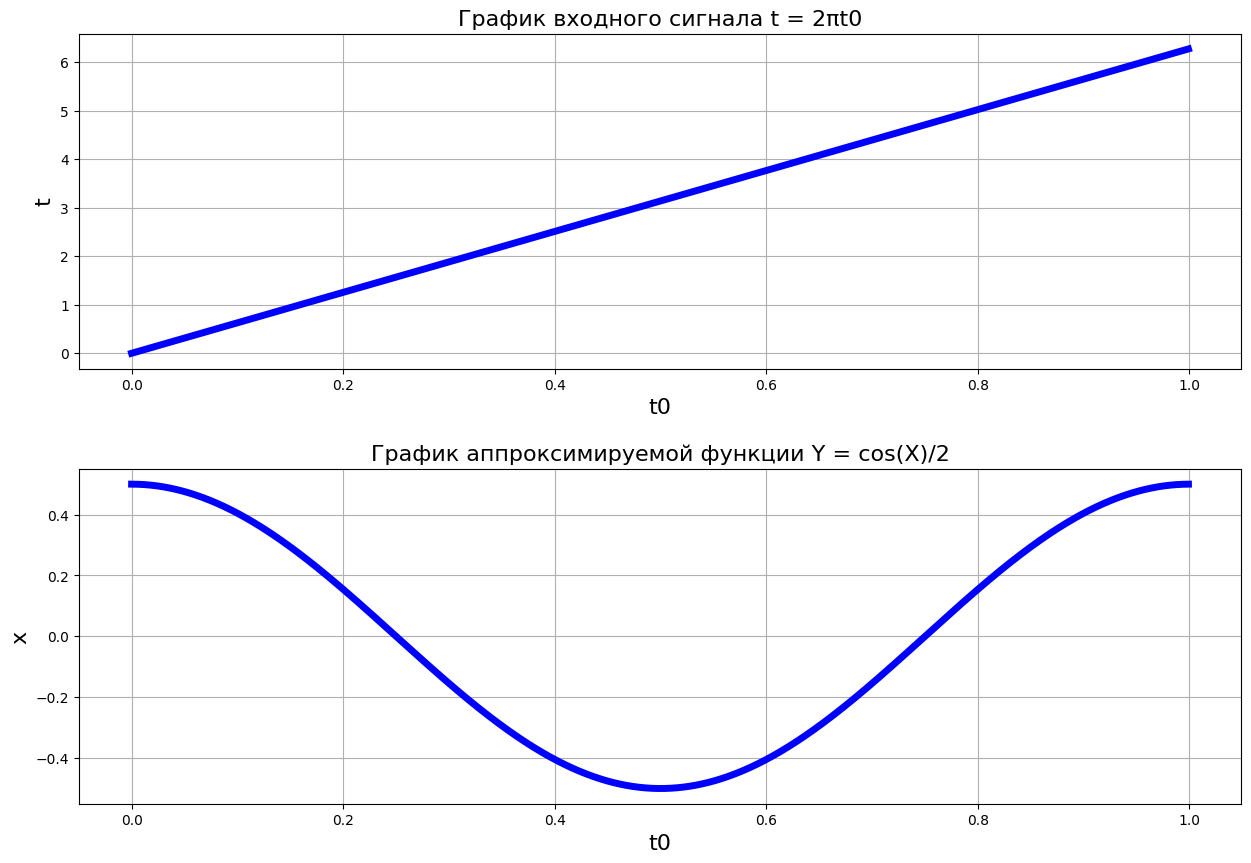

In [50]:
# Прорисовка графиков обучающей выборки
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(t0, t, "b", linewidth=5)
plt.title("График входного сигнала t = 2πt0", fontsize=16)
plt.ylabel("t", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t0, x, "b", linewidth=5)
plt.title("График аппроксимируемой функции Y = cos(X)/2", fontsize=16)
plt.ylabel("x", fontsize=16)
plt.xlabel("t0", fontsize=16)
plt.grid()

plt.subplots_adjust(wspace=0, hspace=0.3)  # задаёт зазор между графиками
plt.show()

In [51]:
# Модель полносвязной сети для аппроксимации функции
class NNCos(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # два скрытых слоя по 50 нейронов с ReLU
        self.fc1 = nn.Linear(in_features, 50)
        self.fc2 = nn.Linear(50, 50)
        # выходной слой: одно значение функции
        self.fc3 = nn.Linear(50, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)            # для регрессии выход обычно без активации
        return x

In [52]:
# Создание модели
model_cos = NNCos(in_features=1).to(device)

# Вариант 1. Простой текстовый вывод
print("=== Структура модели (print) ===")
print(model_cos)

=== Структура модели (print) ===
NNCos(
  (fc1): Linear(in_features=1, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=1, bias=True)
  (act): ReLU()
)


In [53]:
# Вариант 2. torchsummary
print("\n=== Структура модели (torchsummary) ===")
summary(model_cos, input_size=(1,))


=== Структура модели (torchsummary) ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]             100
              ReLU-2                   [-1, 50]               0
            Linear-3                   [-1, 50]           2,550
              ReLU-4                   [-1, 50]               0
            Linear-5                    [-1, 1]              51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [54]:
# Вариант 3. torchinfo (расширенный summary)
print("\n=== Структура модели (torchinfo) ===")
info_summary(model_cos, input_size=(32, 1))  # batch_size=32, 1 признак


=== Структура модели (torchinfo) ===


Layer (type:depth-idx)                   Output Shape              Param #
NNCos                                    [32, 1]                   --
├─Linear: 1-1                            [32, 50]                  100
├─ReLU: 1-2                              [32, 50]                  --
├─Linear: 1-3                            [32, 50]                  2,550
├─ReLU: 1-4                              [32, 50]                  --
├─Linear: 1-5                            [32, 1]                   51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.01
Estimated Total Size (MB): 0.04


=== Структура модели (torchview) ===


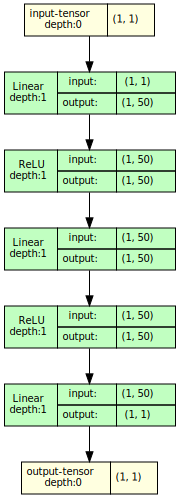

In [55]:
# Вариант 4. torchview (графическая схема сети)
print("\n=== Структура модели (torchview) ===")
graph = draw_graph(
        model_cos,
        input_size=(1, 1),   # (batch_size, число признаков)
        device=device,
        expand_nested=True
)
# Отображаем граф сети прямо в ноутбуке (SVG/PNG)
graph.visual_graph

In [56]:
# Подготовка данных для PyTorch
# t0  – значения аргумента (от 0 до 1 с шагом 0.001)
# x   – значения аппроксимируемой функции cos(2πt)/2
X_train = torch.from_numpy(t0.reshape(-1, 1)).to(device)
y_train = torch.from_numpy(x.reshape(-1, 1)).to(device)

# Параметры обучения
n_epochs   = 100         # число проходов по всему набору данных
batch_size = 30          # размер мини‑батча
criterion  = nn.MSELoss()              # функция потерь (MSE)
optimizer  = optim.Adam(model_cos.parameters(), lr=0.01)  # оптимизатор Adam

history = []  # здесь будем накапливать значение ошибки на каждой эпохе

for epoch in range(n_epochs):
    model_cos.train()                    # переводим модель в режим обучения
    permutation = torch.randperm(X_train.size(0))  # случайное перемешивание индексов

    epoch_loss = 0.0
    # цикл по мини‑батчам
    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i + batch_size]  # выбираем индексы текущего батча
        batch_x = X_train[idx]              # входы батча
        batch_y = y_train[idx]              # целевые значения батча

        optimizer.zero_grad()               # обнуляем градиенты
        y_pred = model_cos(batch_x)         # прямое распространение (forward)
        loss = criterion(y_pred, batch_y)   # вычисляем значение функции потерь
        loss.backward()                     # обратное распространение (backward)
        optimizer.step()                    # делаем шаг градиентного спуска

        epoch_loss += loss.item()           # аккумулируем ошибку по батчам

    history.append(epoch_loss)              # сохраняем суммарную ошибку за эпоху
    if (epoch + 1) % 20 == 0:               # периодический вывод прогресса
        print(f"Epoch {epoch+1:3d}/{n_epochs}, loss = {epoch_loss:.6f}")


Epoch  20/100, loss = 0.006378
Epoch  40/100, loss = 0.002295
Epoch  60/100, loss = 0.001072
Epoch  80/100, loss = 0.003878
Epoch 100/100, loss = 0.009168


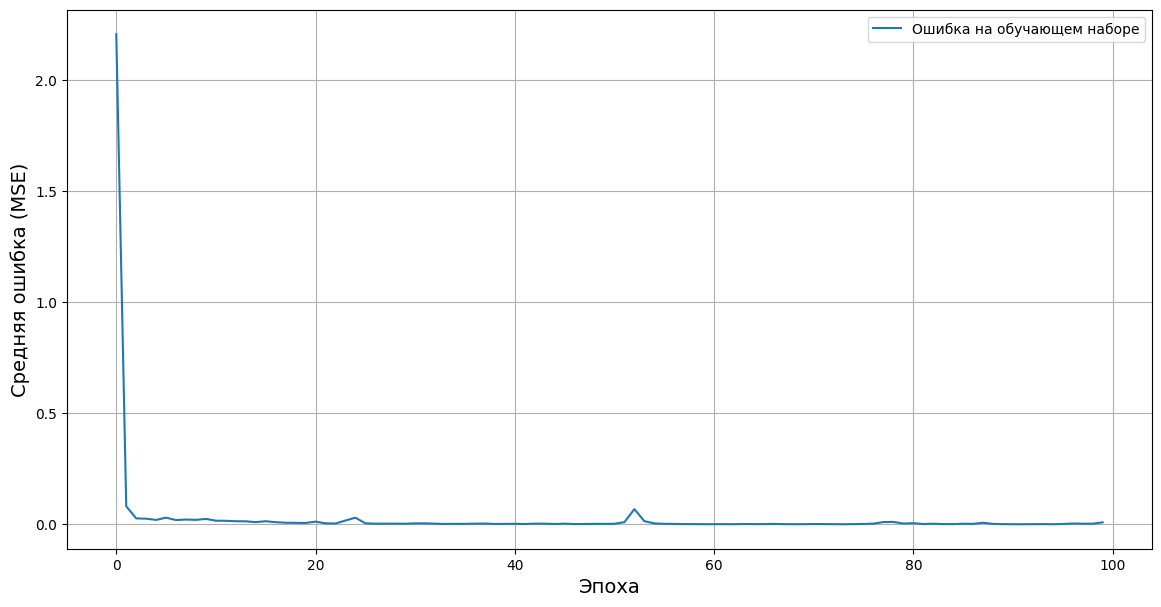

In [57]:
# Вывод графика процесса обучения
plt.figure(figsize=(14, 7))
plt.plot(history, label='Ошибка на обучающем наборе')
plt.ylabel('Средняя ошибка (MSE)', fontsize=14)
plt.xlabel('Эпоха', fontsize=14)
plt.grid()
plt.legend()
plt.show()

In [58]:
# Функция для расчёта MSE
def compute_mse(y_true_tensor, y_pred_tensor):
    """
    y_true_tensor, y_pred_tensor: тензоры PyTorch одинаковой формы
    """
    return torch.mean((y_true_tensor - y_pred_tensor) ** 2).item()

In [59]:
# Моделирование работы НС (получение предсказаний)
model_cos.eval()  # режим оценки (выключает dropout, batchnorm и т.п.)
with torch.no_grad():
    # X_train уже содержит t0 в виде тензора (N, 1)
    pred_test_tensor = model_cos(X_train)
    pred_test = pred_test_tensor.cpu().numpy().ravel()  # в NumPy для графика

    # Расчёт MSE на обучающей выборке
    train_mse = compute_mse(y_train, pred_test_tensor)
    print(f"MSE (train) = {train_mse:.6f}")

MSE (train) = 0.000562


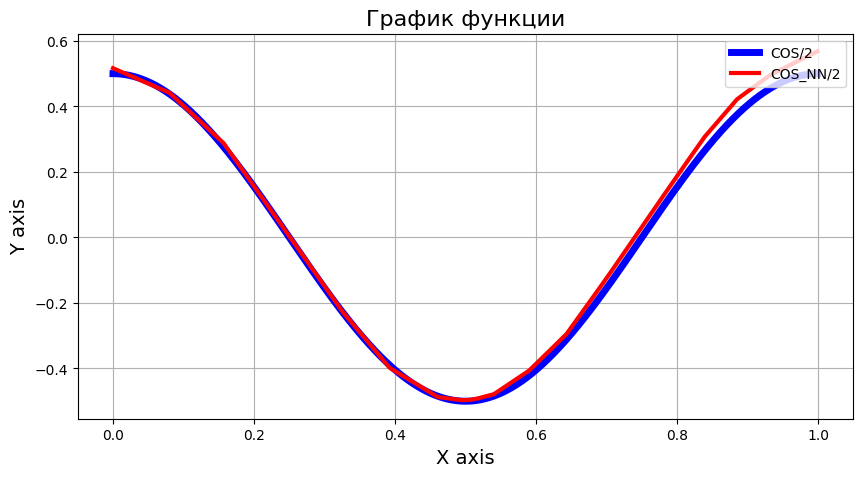

In [60]:
# Вывод графиков с результатом моделирования
plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='COS/2')
plt.plot(t0, pred_test, 'r', linewidth=3, label='COS_NN/2')
plt.title("График функции", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")
plt.show()

In [61]:
# Тестирование на данных, не входящих в обучающую выборку
t0_test = np.arange(0, 2, 0.001, dtype=np.float32)
t_test  = 2 * math.pi * t0_test
x_test  = (np.cos(t_test) / 2).astype(np.float32)

X_test = torch.from_numpy(t0_test.reshape(-1, 1)).to(device)
y_test = torch.from_numpy(x_test.reshape(-1, 1)).to(device)

# Моделирование работы НС (получение предсказаний)
model_cos.eval()
with torch.no_grad():
    y_test_pred_tensor = model_cos(X_test)
    y_test_pred = y_test_pred_tensor.cpu().numpy().ravel()

    # Расчёт MSE на тестовой выборке
    test_mse = compute_mse(y_test, y_test_pred_tensor)
    print(f"MSE (test, NNCos) = {test_mse:.6f}")


MSE (test, NNCos) = 0.675145


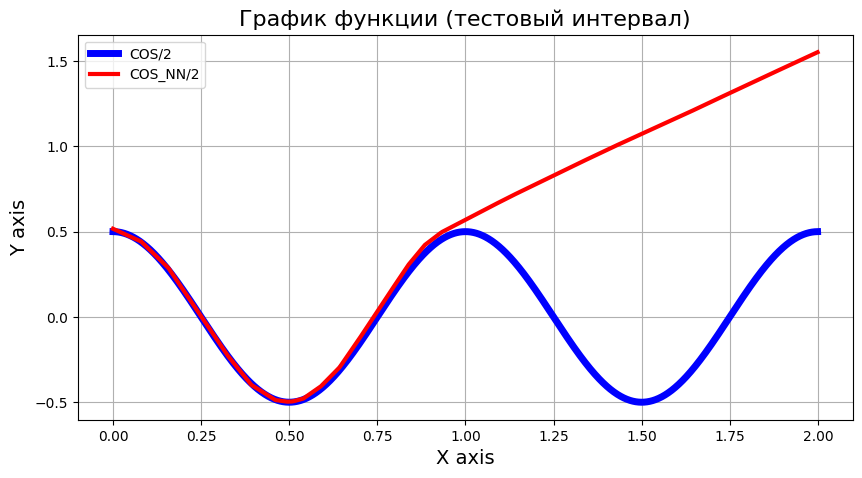

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(t0_test, x_test, 'b', label='COS/2', linewidth=5)
plt.plot(t0_test, y_test_pred, 'r', label='COS_NN/2', linewidth=3)
plt.title("График функции (тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Лабораторная работа №2. Часть 2

## Теоретические сведения
### Ветвящиеся архитектуры

Для решения более сложных задач простой последовательной цепочки слоёв может быть недостаточно. Иногда сети необходимо выделить общую скрытую репрезентацию входа, а затем обработать её параллельно, чтобы извлечь независимые группы признаков.

Ветвящаяся архитектура строится следующим образом:
1. **Общая часть (Shared part):** Входные данные проходят через один или несколько общих слоёв.
2. **Ветви (Branches):** Выход общей части подаётся одновременно на входы нескольких независимых слоёв (веток). Каждая ветвь обучается выделять «свои» специфические закономерности.
3. **Объединение (Merge):** Результаты вычислений из всех ветвей объединяются (чаще всего с помощью конкатенации тензоров по признаковому измерению).
4. **Выходной слой:** Объединённый тензор подаётся на финальный слой для получения итогового предсказания.

В PyTorch такая логика реализуется напрямую внутри метода `forward()`: вы один раз пропускаете тензор через общие слои, сохраняете результат в промежуточную переменную, а затем подаёте эту переменную в каждую из ветвей. Результаты ветвей объединяются функцией `torch.cat`.

Одним из классических примеров ветвящейся архитектуры является Unet для задач сегментации изображений. В ней:

- **энкодер** (нисходящая часть) поэтапно уменьшает размер карты признаков, увеличивая число каналов и извлекая всё более абстрактные признаки;
- **декодер** (восходящая часть) восстанавливает пространственное разрешение с помощью операций upsampling / transposed‑conv;
- между соответствующими уровнями энкодера и декодера используются **skip‑соединения**: карты признаков из энкодера конкатенируются с картами декодера. Таким образом реализуются ветви, которые передают в декодер как высокоуровневые признаки, так и детальную пространственную информацию.

С точки зрения общей схемы, Unet как раз иллюстрирует идею *общей части + нескольких ветвей + объединения (concatenate)*, только в более сложном, многоуровневом варианте.

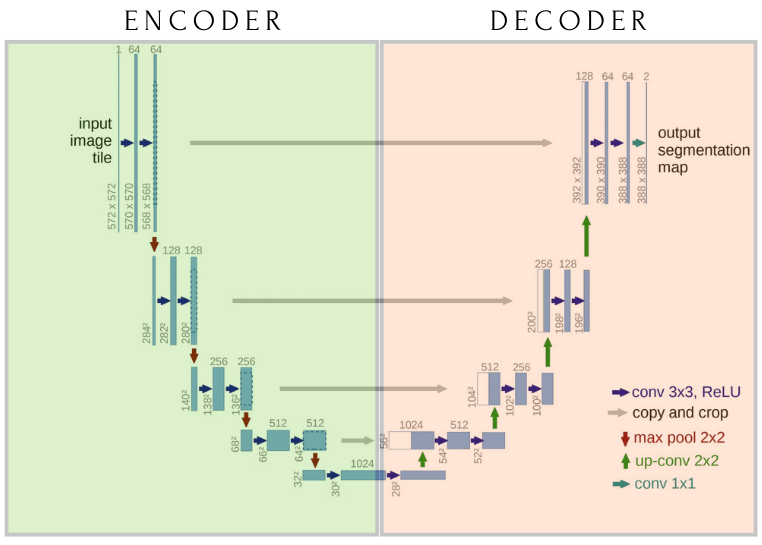

In [63]:
# Ветвящаяся модель для аппроксимации функции
class BranchCos(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # основная ветка: два скрытых слоя по 50 нейронов с ReLU
        self.fc_main1 = nn.Linear(in_features, 50)
        self.fc_main2 = nn.Linear(50, 50)

        # параллельная ветка: один слой 50 нейронов с Sigmoid от исходного входа
        self.fc_branch1 = nn.Linear(in_features, 50)

        # выходной слой: после конкатенации 50 + 50 = 100 признаков
        self.fc_out = nn.Linear(100, 1)

        self.act_relu = nn.ReLU()
        self.act_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # основная ветка
        x_main = self.act_relu(self.fc_main1(x))
        x_main = self.act_relu(self.fc_main2(x_main))

        # параллельная ветка
        x_branch = self.act_sigmoid(self.fc_branch1(x))

        # конкатенация двух ветвей по признаковому измерению
        x_concat = torch.cat([x_main, x_branch], dim=1)

        # выход без активации (регрессия)
        out = self.fc_out(x_concat)
        return out


=== Структура ветвящейся модели (torchview) ===


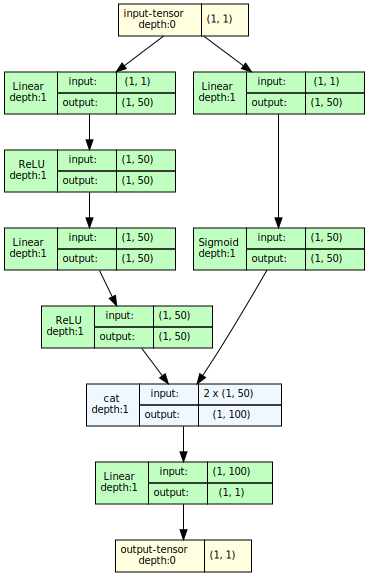

In [64]:
# Создание модели
model_branch = BranchCos(in_features=1).to(device)

print("\n=== Структура ветвящейся модели (torchview) ===")
graph_branch = draw_graph(
    model_branch,
    input_size=(1, 1),   # (batch_size, число признаков)
    device=device,
    expand_nested=True
)
graph_branch.visual_graph

In [65]:
# torchsummary
summary(model_branch, input_size=(1,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]             100
              ReLU-2                   [-1, 50]               0
            Linear-3                   [-1, 50]           2,550
              ReLU-4                   [-1, 50]               0
            Linear-5                   [-1, 50]             100
           Sigmoid-6                   [-1, 50]               0
            Linear-7                    [-1, 1]             101
Total params: 2,851
Trainable params: 2,851
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [66]:
# Подготовка данных для PyTorch
X_train = torch.from_numpy(t0.reshape(-1, 1)).to(device)
y_train = torch.from_numpy(x.reshape(-1, 1)).to(device)

# Параметры обучения
n_epochs   = 100
batch_size = 30
criterion  = nn.MSELoss()
optimizer_branch = optim.Adam(model_branch.parameters(), lr=0.01)

history_branch = []  # здесь будем накапливать значение ошибки на каждой эпохе

for epoch in range(n_epochs):
    model_branch.train()
    permutation = torch.randperm(X_train.size(0))

    epoch_loss = 0.0
    # цикл по мини‑батчам
    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i + batch_size]
        batch_x = X_train[idx]
        batch_y = y_train[idx]

        optimizer_branch.zero_grad()
        y_pred = model_branch(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer_branch.step()

        epoch_loss += loss.item()

    history_branch.append(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(f"[Branch] Epoch {epoch+1:3d}/{n_epochs}, loss = {epoch_loss:.6f}")

[Branch] Epoch  20/100, loss = 0.008327
[Branch] Epoch  40/100, loss = 0.002556
[Branch] Epoch  60/100, loss = 0.002423
[Branch] Epoch  80/100, loss = 0.006544
[Branch] Epoch 100/100, loss = 0.044429


MSE (train, BranchCos) = 0.007870


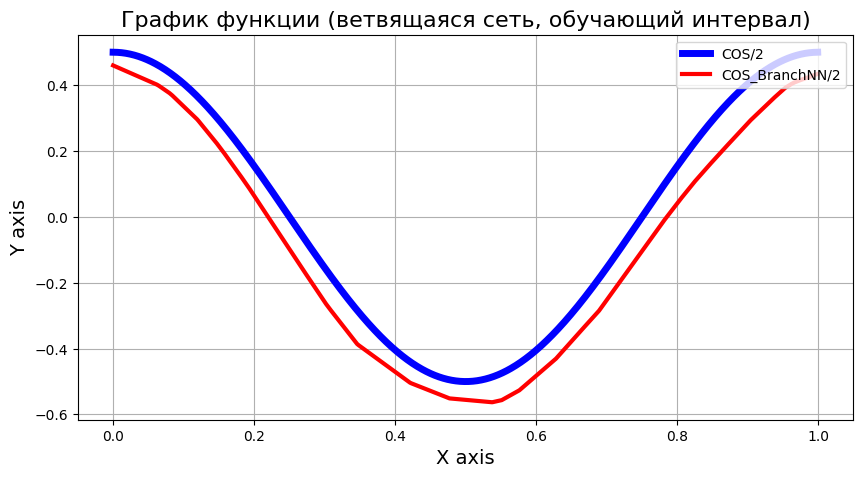

In [67]:
# Моделирование работы ветвящейся НС (обучающий интервал)
model_branch.eval()
with torch.no_grad():
    pred_branch_train_tensor = model_branch(X_train)
    pred_branch_train = pred_branch_train_tensor.cpu().numpy().ravel()

    # Расчёт MSE на обучающей выборке для ветвящейся сети
    branch_train_mse = compute_mse(y_train, pred_branch_train_tensor)
    print(f"MSE (train, BranchCos) = {branch_train_mse:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(t0, x, 'b', linewidth=5, label='COS/2')
plt.plot(t0, pred_branch_train, 'r', linewidth=3, label='COS_BranchNN/2')
plt.title("График функции (ветвящаяся сеть, обучающий интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend(loc="upper right")

MSE (test, BranchCos) = 0.424070


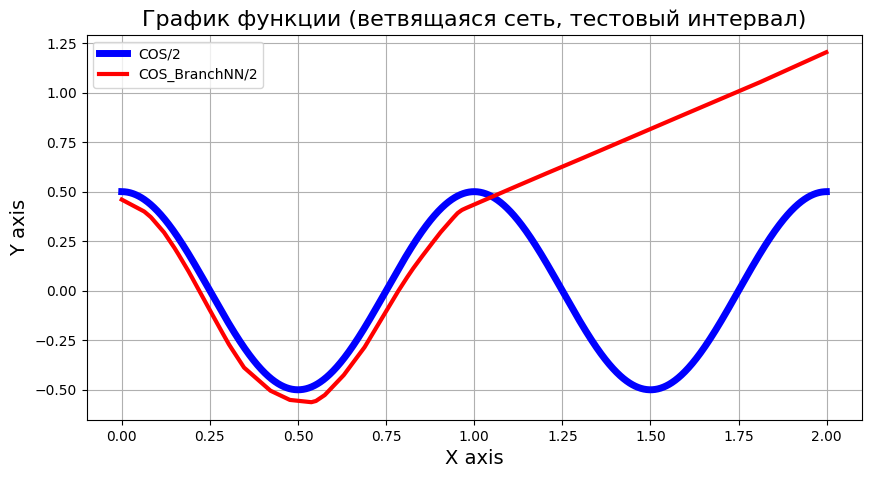

In [68]:
# Тестирование на данных, не входящих в обучающую выборку
t0_test = np.arange(0, 2, 0.001, dtype=np.float32)
t_test  = 2 * math.pi * t0_test
x_test  = (np.cos(t_test) / 2).astype(np.float32)

X_test = torch.from_numpy(t0_test.reshape(-1, 1)).to(device)
y_test = torch.from_numpy(x_test.reshape(-1, 1)).to(device)

model_branch.eval()
with torch.no_grad():
    y_branch_test_tensor = model_branch(X_test)
    y_branch_test = y_branch_test_tensor.cpu().numpy().ravel()

    # Расчёт MSE на тестовом интервале для ветвящейся сети
    branch_test_mse = compute_mse(y_test, y_branch_test_tensor)
    print(f"MSE (test, BranchCos) = {branch_test_mse:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(t0_test, x_test, 'b', label='COS/2', linewidth=5)
plt.plot(t0_test, y_branch_test, 'r', label='COS_BranchNN/2', linewidth=3)
plt.title("График функции (ветвящаяся сеть, тестовый интервал)", fontsize=16)
plt.ylabel('Y axis', fontsize=14)
plt.xlabel('X axis', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Порядок выполнения работы

1. Студент выбирает номер варианта согласно списку группы.  
2. По номеру варианта выбирается целевая **нелинейная** функция \(Y=f(X)\) из таблицы вариантов.  
3. Сгенерировать обучающую выборку \((X, Y)\) на интервале, указанном преподавателем (например, \(X \in [0, 2\pi]\)), добавить тестовый интервал, не пересекающийся с обучающим.  
4. Реализовать в PyTorch две модели:
   - последовательную полносвязную сеть (NNSin);
   - ветвящуюся сеть (BranchSin) с двумя параллельными ветвями и последующей конкатенацией признаков.
5. Обучить обе сети на одной и той же выборке, подобрать гиперпараметры (число эпох, размер батча, скорость обучения) так, чтобы добиться разумной аппроксимации функции.
6. Сравнить качество:
   - по графикам на обучающем и тестовом интервале;
   - по числовым метрикам (MSE на обучающей и тестовой выборках);
   - по сложности модели (число параметров), форме графа сети (torchinfo / torchview).
7. Заполнить таблицу экспериментов, сделать краткие выводы о влиянии архитектуры (последовательная vs ветвящаяся) и гиперпараметров на качество аппроксимации.

### Таблица вариантов

| № варианта | Функция              |
|-----------:|----------------------|
| 6          | Y = cos(X)/2         |


Примечание. При работе с функциями tan(X) и cot(X) выбирайте такой диапазон X,
чтобы избежать точек разрыва и деления на ноль (например, не брать точки
в окрестности X = π/2 + kπ, k ∈ Z).

### Сравнительная таблица экспериментов

#### Модель 1: NNCos (последовательная) 2701 параметров

| № эксперимента | Описание настройки (слои, LR, batch, эпохи) | MSE train | MSE test |
|----------------|---------------------------------------------|-----------|----------|
| 1              | 2 скрытых слоя по 50 (ReLU), LR=0.01, batch=30, 100 эпох | 0.000670  | 0.506192 |

#### Модель 2: BranchCos (ветвящаяся) 2851 параметров

| № эксперимента | Описание настройки (ветви, LR, batch, эпохи) | MSE train | MSE test |
|----------------|----------------------------------------------|-----------|----------|
| 1              | Основная ветвь: 2 с.с. по 50 (ReLU), побочная: 1 с.с. 50 (Sigmoid), LR=0.01, batch=30, 100 эпох | 0.000093  | 0.569898 |

#### Общий вывод по моделям

| Модель    | Лучшая конфигурация (кратко) | Лучший MSE train | Лучший MSE test | Итоговый вывод (1–2 предложения) |
|-----------|------------------------------|------------------|-----------------|----------------------------------|
| NNCos     | 2×50, ReLU, LR=0.01, batch=30, 100 эпох | 0.000670 | 0.506192 | на обучающих данных сеть хорошо выучила функцию, но на тестовых данных ошибка большая, за пределами обучающего интервала сеть предсказывает плохо. |
| BranchCos | Main 2×50 ReLU + Branch 1×50 Sigmoid, LR=0.01, batch=30, 100 эпох | 0.000093 | 0.569898 | ветвящаяся сеть лучше обучилась на тренировочных данных (MSE в 7 раз меньше), но на тесте результат примерно такой же, обе сети не умеют предсказывать значения функции за пределами обучающего диапазона. |

## Контрольные вопросы

1. В чём принципиальное отличие последовательной и ветвящейся архитектуры нейросети при аппроксимации функции одной переменной?

В последовательной сети данные проходят через слои один за другим по цепочке. В ветвящейся после общих слоев данные идут параллельно по нескольким ветвям, каждая обрабатывает вход по-своему, а потом результаты склеиваются и подаются на выход. Это позволяет извлекать разные типы признаков одновременно.

2. Как выбор активационных функций (ReLU, Sigmoid, Tanh) влияет на способность модели аппроксимировать заданную нелинейную функцию?

ReLU — простая и быстрая, но приближает функцию ломаными линиями. Sigmoid и Tanh — дают более плавный результат, поэтому лучше подходят для гладких функций вроде cos или sin.

3. Зачем в экспериментах разделяют обучающий и тестовый интервалы по X и что будет, если обучать и тестировать на одном и том же диапазоне?

Чтобы проверить, как сеть работает на данных, которые она не видела при обучении. Если обучать и тестировать на одном диапазоне, не узнать, действительно ли сеть поняла закономерность или просто запомнила данные. В ЛР обе сети хорошо работали на обучающем интервале, но плохо на тестовом, что как раз показало что сети не выучили саму формулу cos(X)/2, а просто запомнили значения на обучающем интервале.

4. Как изменение числа эпох, размера батча и скорости обучения отражается на MSE на обучающей и тестовой выборках?

Больше эпох - сеть дольше учится и результаты получаются лучше, но если переборщить, может быть переобучение. Маленький батч - сеть обновляется чаще и может найти результат точнее, большой батч - обучение плавнее, но результат может быть хуже. Высокая скорость обучения - сеть учится быстро, но может перепрыгнуть нужное значение, низкая - учится медленно, но точнее.

5. Какие преимущества и недостатки даёт ветвящаяся архитектура (BranchSin) по сравнению с простой полносвязной сетью при аппроксимации сложных нелинейных функций?

Преимущества: разные ветви с разными активациями извлекают разные признаки, что даёт лучшее качество на обучении.

Недостатки: больше параметров, сложнее в реализация, а на тестовых данных за пределами обучающего диапазона результат всё равно примерно такой же, обе сети не умеют предсказывать значения функции за пределами обучающего диапазона.